# Training of ML solution

#### [Applying machine learning on sensor data for irrigation recommendations: revealing the agronomist’s tacit knowledge](https://link.springer.com/article/10.1007/s11119-017-9527-4), [Precision Agriculture](https://link.springer.com/journal/11119), 2018

In [137]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, classification_report, make_scorer
import matplotlib.pyplot as plt
from joblib import dump

In [138]:
    #     SELECT 
    #     date, 
    #     "fieldName", 
    #     "sectorName", 
    #     CASE 
    #         WHEN yy > -40 THEN -20
    #         WHEN yy <= -40 THEN -60
    #     END AS yy_grouped,
    #     AVG(value) AS value
    # FROM view_data_original
    # WHERE ("fieldName" ILIKE '%Errano%')
    # AND "sectorName" = 'T0'
    # AND "detectedValueTypeId" LIKE '%GRND%'
    # AND yy <= -20


weather_file = os.path.join("/", "home", "data", "ml_data", "raw_data", "weather_1day.csv")
irrigation_groundtruth_file = os.path.join("/", "home", "data", "ml_data", "raw_data", "irrigation_1day.csv")
soil_moisture_file = os.path.join("/", "home", "data", "ml_data", "raw_data", "soil_moisture_1day.csv")

weather_dataset = pd.read_csv(weather_file)
irrigation_dataset = pd.read_csv(irrigation_groundtruth_file)
soil_moisture_dataset = pd.read_csv(soil_moisture_file)

ml_model_output_path = os.path.join("/", "home", "processing", "MLModels")

#### Preprocessing data

In [139]:
# Removing useless meteo variables
weather_dataset = weather_dataset.loc[weather_dataset["detectedValueTypeId"].isin(["AIR_HUM","AIR_TEMP","SOLAR_RAD",])]
weather_dataset["value"] = weather_dataset["value"].apply(lambda row: round(row,2))

# Pivoting weather data
weather_dataset = weather_dataset.pivot_table(
    index=["date", "fieldName", "sectorName"],
    columns="detectedValueTypeId",
    values="value"
).reset_index()
weather_dataset.dropna(subset=["AIR_HUM"], inplace=True)


soil_moisture_dataset["yy"] = soil_moisture_dataset["yy"].apply(lambda x : abs(x))
soil_moisture_dataset["value"] = soil_moisture_dataset["value"].apply(lambda row: round(row,2))

# Pivoting moisture data
soil_moisture_dataset = soil_moisture_dataset.pivot_table(
    index=["date", "fieldName", "sectorName"],
    columns="yy",
    values="value"
).reset_index()

soil_moisture_dataset = soil_moisture_dataset.rename(columns={20 : 'moistureDepth20cm', 60 : 'moistureDepth60cm'})
soil_moisture_dataset.dropna(subset=["moistureDepth60cm"], inplace=True)
soil_moisture_dataset.dropna(subset=["moistureDepth20cm"], inplace=True)

# Unifying field name across years
weather_dataset["fieldName"] = "Fondo Errano"
irrigation_dataset["fieldName"] = "Fondo Errano"
soil_moisture_dataset["fieldName"] = "Fondo Errano"

# Create dataset
dataset = soil_moisture_dataset.merge(weather_dataset, on = ["date","fieldName","sectorName"], how = 'inner').merge(irrigation_dataset,on = ["date","fieldName","sectorName"], how = 'inner')

# Removing useless categorical attributes
dataset = dataset.drop(columns=["fieldName","sectorName"])

dataset["date"] = pd.to_datetime(dataset["date"])
data = dataset.sort_values("date").reset_index(drop=True)

print(f"Dataset has now {len(dataset)} rows with \n{dataset.isna().sum()}\n null values")

Dataset has now 1272 rows with 
date                 0
moistureDepth20cm    0
moistureDepth60cm    0
AIR_HUM              0
AIR_TEMP             0
SOLAR_RAD            0
irrigation           0
dtype: int64
 null values


#### Add forecasts, IPPD, saturation and drought data

In [140]:
meteo_cols = ["AIR_HUM", "AIR_TEMP", "SOLAR_RAD"]
window = 1 # days
for col in meteo_cols:
    dataset[f"{col}_forecast"] = dataset[col].shift(-1)
    dataset.loc[dataset.index[-1], f"{col}_forecast"] = dataset.loc[dataset.index[-1], col]

    dataset[f"{col}_IPPD"] = dataset[col].shift(1)
    dataset.loc[dataset.index[0], f"{col}_IPPD"] = dataset.loc[dataset.index[0], col]

for depth in [20, 60]:
    col = f"moistureDepth{depth}cm"

    dataset[f"drought_duration_{depth}cm"] = (
        (dataset[col] <= -300)
        .astype(int)
        .rolling(window=window, min_periods=1)
        .sum()
    )

    # Saturation duration negli ultimi 7 giorni
    dataset[f"saturation_duration_{depth}cm"] = (
        (dataset[col] >= -50)
        .astype(int)
        .rolling(window=window, min_periods=1)
        .sum()
    )

## Utility functions

In [141]:
def change_time_granularity(df: pd.DataFrame, days: int) -> pd.DataFrame:
    data = df.copy()

    start_date = data["date"].min()
    data["group"] = ((data["date"] - start_date).dt.days // days)

    agg_dict = {
        "moistureDepth20cm": "mean",
        "moistureDepth60cm": "mean",
        "AIR_HUM": "mean",
        "AIR_TEMP": "mean",
        "SOLAR_RAD": "mean",
        "irrigation": "sum",
        "AIR_HUM_forecast": "mean",
        "AIR_HUM_IPPD": "mean",
        "AIR_TEMP_forecast": "mean",
        "AIR_TEMP_IPPD": "mean",
        "SOLAR_RAD_forecast": "mean",
        "SOLAR_RAD_IPPD": "mean",
        "drought_duration_20cm": "sum",
        "saturation_duration_20cm": "sum",
        "drought_duration_60cm": "sum",
        "saturation_duration_60cm": "sum"
    }

    df_grouped = data.groupby("group").agg(agg_dict)
    df_grouped["date"] = data.groupby("group")["date"].min()
    df_grouped = df_grouped.reset_index(drop=True).sort_values("date")

    return df_grouped

def split_dataset_by_year(dataset: pd.DataFrame, year: int):
    train_mask = dataset["date"].dt.year < year
    test_mask = dataset["date"].dt.year >= year

    X_train = dataset.loc[train_mask].drop(columns=["irrigation"])
    X_train["date"] = X_train["date"].dt.isocalendar().week
    y_train = dataset.loc[train_mask, "irrigation"]

    X_test = dataset.loc[test_mask].drop(columns=["irrigation"])
    X_test["date"] = X_test["date"].dt.isocalendar().week
    y_test = dataset.loc[test_mask, "irrigation"]
    return X_train, X_test, y_train, y_test

def predictedVSTruth(y_true, y_pred, n=20, title="Predicted vs Truth", random_state=42):
    import matplotlib.pyplot as plt
    import numpy as np

    np.random.seed(random_state)
    indices = np.random.choice(len(y_true), size=min(n, len(y_true)), replace=False)

    y_true_sample = y_true[indices]
    y_pred_sample = y_pred[indices]

    x = np.arange(len(y_true_sample))
    width = 0.4

    plt.figure(figsize=(max(10, len(y_true_sample)*0.5), 6))
    plt.bar(x - width/2, y_true_sample, width, label="Truth")
    plt.bar(x + width/2, y_pred_sample, width, label="Predicted")

    plt.xticks(x, [i+1 for i in x])

    plt.xlabel("Observations")
    plt.ylabel("Irrigation")
    plt.title(title)
    plt.legend()
    plt.show()

### Gradient Boost Regression Tree

#### Hyperparameter optimization through AutoML - Gradient Boost Regression Trees

X_train: (894, 16)
X_test: (378, 16)
y_train: (894,)
y_test: (378,)


Best parameters: {'subsample': np.float64(0.7), 'n_estimators': np.int64(100), 'min_samples_split': np.int64(9), 'min_samples_leaf': np.int64(7), 'max_depth': np.int64(2), 'learning_rate': np.float64(0.01)}
Sampling for 1 days
RMSE: 4.579, R²: 0.069


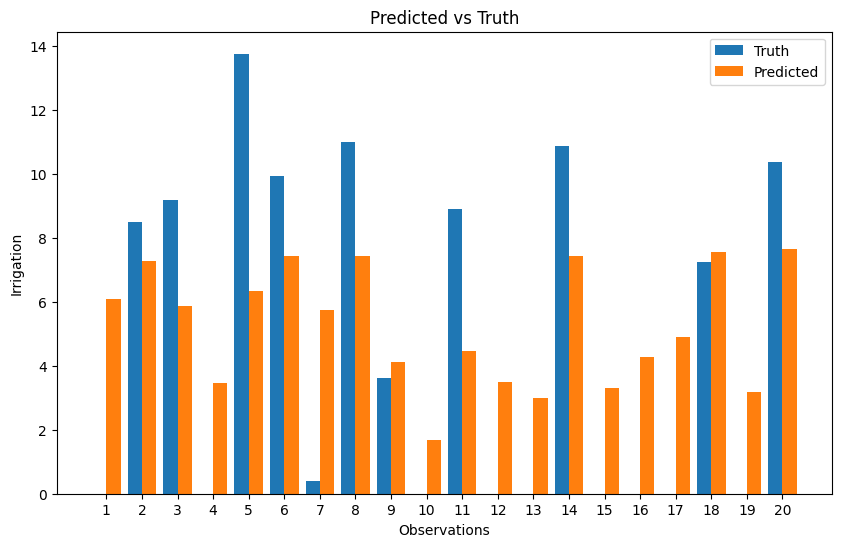

In [145]:
iterations = [1]

for iteration in iterations:
    df = dataset.copy(deep=True)
    if iteration > 1:
        df = change_time_granularity(df, iteration)
    else:
        dates = df["date"]
        df.drop(columns=["date"], inplace=True)
        df["date"] = dates

    X_train, X_test, y_train, y_test = split_dataset_by_year(df, 2024)

    print(f"X_train: {X_train.shape}")
    print(f"X_test: {X_test.shape}")
    print(f"y_train: {y_train.shape}")
    print(f"y_test: {y_test.shape}")

    gbr = GradientBoostingRegressor(random_state=42)

    param_dist = {
        "n_estimators": np.arange(100, 1001, 100),    # numero di alberi
        "learning_rate": np.linspace(0.01, 0.2, 20),  # tasso di apprendimento
        "max_depth": np.arange(2, 8),                 # profondità massima degli alberi
        "subsample": np.linspace(0.6, 1.0, 5),        # frazione di campioni per albero
        "min_samples_split": np.arange(2, 11),        # minimo campioni per split
        "min_samples_leaf": np.arange(1, 11)          # minimo campioni in foglia
    }

    rmse_scorer = make_scorer(lambda y_true, y_pred: -np.sqrt(mean_squared_error(y_true, y_pred)))

    random_search = RandomizedSearchCV(
        estimator=gbr,
        param_distributions=param_dist,
        n_iter=600,              # numero di combinazioni da provare
        scoring=rmse_scorer,
        cv=3,
        verbose=0,
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    print("Best parameters:", random_search.best_params_)

    best_gbr = random_search.best_estimator_

    y_pred = best_gbr.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"Sampling for {iteration} days")
    print(f"RMSE: {rmse:.3f}, R²: {r2:.3f}")

    dump(best_gbr, os.path.join(ml_model_output_path, f"GBRT_Prediction_{iteration}days.joblib"))

    predictedVSTruth(y_test.values, y_pred, n=20)

Total tuples: 1272
Tuples with irrigation = 0: 732
Tuples with irrigation > 0:  540
month
1      31
2      28
3      32
4      76
5     166
6     177
7     186
8     184
9     180
10    122
11     58
12     32
Name: irrigation, dtype: int64


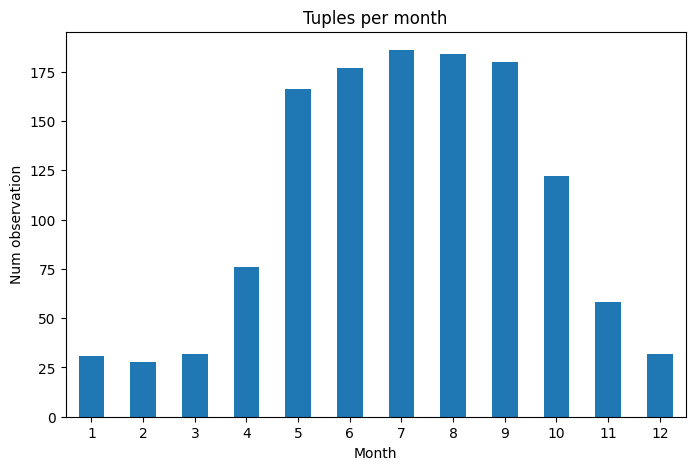

In [106]:
print(f"Total tuples: {len(dataset)}")
print(f"Tuples with irrigation = 0: {len(dataset.loc[dataset["irrigation"] == 0])}")
print(f"Tuples with irrigation > 0:  {len(dataset) - len(dataset.loc[dataset["irrigation"] == 0])}")

dataset["date"] = pd.to_datetime(dataset["date"])
dataset["month"] = dataset["date"].dt.month
counts = dataset.groupby("month")["irrigation"].count()
print(counts)
plt.figure(figsize=(8,5))
counts.plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Num observation")
plt.title("Tuples per month")
plt.xticks(rotation=0)
plt.show()

### Gradient Boosting Classification Tree